In [1]:
from pathlib import Path
from itertools import product

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_security.csv"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: /Users/mustafaahmed/Documents/Security Code Review Analysis
Dataset path: /Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/final_security.csv
Dataset exists: True


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (9230, 13)

Columns:
['comment_id', 'comment', 'repo', 'language', 'pr_id', 'c_id', 'matched_strong', 'matched_weak', 'security_categories', 'candidate_score', 'indicator_strength', 'security_label', 'review_notes']


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,security_label,review_notes
0,208849771,Should not `ansible.utils.encrypt.random_passw...,ansible,Python,21225735,1095841089,NaN,password; encryption,authentication; cryptography,2,weak,0,"Keyword appears while describing, implementing..."
1,258431281,These routes are quite a lot to copy in here. ...,AspNetCore,NaN,56148722,1303642745,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
2,269690752,slow-tests does also contain ssl-certificate r...,chainweb-node,Haskell,58703769,1341744273,NaN,ssl; certificate,cryptography,2,weak,0,"Keyword appears while describing, implementing..."
3,195074858,minikube start --bootstrapper localkube --extr...,service-manager,NaN,39143713,1005582331,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
4,224629987,There might be some confusion. I ran this cod...,hail,Scala,47236096,1161354134,NaN,secret; session,authentication; secrets,2,weak,1,Comment explicitly describes a security weakne...


In [4]:
df_binary = df[df["security_label"].isin([0, 1])].copy()

df_binary["label"] = df_binary["security_label"].astype(int)

df_binary["comment"] = df_binary["comment"].fillna("").astype(str)

df_binary = df_binary[
    ["comment", "label"]
].reset_index(drop=True)

print("Binary dataset shape:", df_binary.shape)

print("\nLabel distribution:")
print(df_binary["label"].value_counts().sort_index())

print("\nLabel proportions:")
print(df_binary["label"].value_counts(normalize=True).sort_index())

Binary dataset shape: (9147, 2)

Label distribution:
label
0    6119
1    3028
Name: count, dtype: int64

Label proportions:
label
0    0.668963
1    0.331037
Name: proportion, dtype: float64


In [5]:
X = df_binary["comment"]
y = df_binary["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting label distribution:")
print(y_test.value_counts().sort_index())

Training examples: 7317
Testing examples: 1830

Training label distribution:
label
0    4895
1    2422
Name: count, dtype: int64

Testing label distribution:
label
0    1224
1     606
Name: count, dtype: int64


In [6]:
ngram_configurations = {
    "unigrams": (1, 1),
    "unigrams_bigrams": (1, 2)
}

class_weight_configurations = {
    "unweighted": None,
    "balanced": "balanced"
}

model_configurations = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        random_state=42
    )
}

In [7]:
experiment_results = []
experiment_predictions = {}

for ngram_name, ngram_range in ngram_configurations.items():

    print("=" * 80)
    print("TF-IDF configuration:", ngram_name)
    print("N-gram range:", ngram_range)

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    print("Training TF-IDF shape:", X_train_tfidf.shape)
    print("Testing TF-IDF shape:", X_test_tfidf.shape)

    for weight_name, class_weight in class_weight_configurations.items():

        for model_name, base_model in model_configurations.items():

            print("\nRunning:", model_name, "|", weight_name)

            if model_name == "Logistic Regression":
                model = LogisticRegression(
                    max_iter=2000,
                    class_weight=class_weight,
                    random_state=42
                )
            else:
                model = LinearSVC(
                    class_weight=class_weight,
                    random_state=42
                )

            model.fit(X_train_tfidf, y_train)

            y_pred = model.predict(X_test_tfidf)

            accuracy = accuracy_score(y_test, y_pred)
            balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
            precision = precision_score(
                y_test,
                y_pred,
                zero_division=0
            )
            recall = recall_score(
                y_test,
                y_pred,
                zero_division=0
            )
            f1 = f1_score(
                y_test,
                y_pred,
                zero_division=0
            )

            tn, fp, fn, tp = confusion_matrix(
                y_test,
                y_pred,
                labels=[0, 1]
            ).ravel()

            experiment_name = (
                f"{model_name} | "
                f"{ngram_name} | "
                f"{weight_name}"
            )

            experiment_results.append({
                "experiment": experiment_name,
                "model": model_name,
                "ngram_configuration": ngram_name,
                "class_weight": weight_name,
                "number_of_features": X_train_tfidf.shape[1],
                "accuracy": accuracy,
                "balanced_accuracy": balanced_accuracy,
                "precision": precision,
                "recall": recall,
                "f1_score": f1,
                "true_negative": tn,
                "false_positive": fp,
                "false_negative": fn,
                "true_positive": tp
            })

            experiment_predictions[experiment_name] = {
                "model": model,
                "vectorizer": vectorizer,
                "predictions": y_pred
            }

            print(f"Accuracy:          {accuracy:.4f}")
            print(f"Balanced accuracy: {balanced_accuracy:.4f}")
            print(f"Precision:         {precision:.4f}")
            print(f"Recall:            {recall:.4f}")
            print(f"F1-score:          {f1:.4f}")
            print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

TF-IDF configuration: unigrams
N-gram range: (1, 1)
Training TF-IDF shape: (7317, 5527)
Testing TF-IDF shape: (1830, 5527)

Running: Logistic Regression | unweighted
Accuracy:          0.9590
Balanced accuracy: 0.9381
Precision:         1.0000
Recall:            0.8762
F1-score:          0.9340
TN: 1224, FP: 0, FN: 75, TP: 531

Running: Linear SVM | unweighted
Accuracy:          0.9672
Balanced accuracy: 0.9542
Precision:         0.9840
Recall:            0.9158
F1-score:          0.9487
TN: 1215, FP: 9, FN: 51, TP: 555

Running: Logistic Regression | balanced
Accuracy:          0.9656
Balanced accuracy: 0.9518
Precision:         0.9840
Recall:            0.9109
F1-score:          0.9460
TN: 1215, FP: 9, FN: 54, TP: 552

Running: Linear SVM | balanced
Accuracy:          0.9667
Balanced accuracy: 0.9572
Precision:         0.9690
Recall:            0.9290
F1-score:          0.9486
TN: 1206, FP: 18, FN: 43, TP: 563
TF-IDF configuration: unigrams_bigrams
N-gram range: (1, 2)
Training TF-ID

In [8]:
results_df = pd.DataFrame(experiment_results)

results_df = results_df.sort_values(
    by="f1_score",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1_score": "{:.4f}"
    })
)

,experiment,model,ngram_configuration,class_weight,number_of_features,accuracy,balanced_accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive
0,Linear SVM | unigrams_bigrams | balanced,Linear SVM,unigrams_bigrams,balanced,14862,0.9760,0.9649,0.9947,0.9323,0.9625,1221,3,41,565
1,Linear SVM | unigrams_bigrams | unweighted,Linear SVM,unigrams_bigrams,unweighted,14862,0.9754,0.9633,0.9982,0.9274,0.9615,1223,1,44,562
2,Logistic Regression | unigrams_bigrams | balanced,Logistic Regression,unigrams_bigrams,balanced,14862,0.9705,0.9563,0.9964,0.9142,0.9535,1222,2,52,554
3,Linear SVM | unigrams | unweighted,Linear SVM,unigrams,unweighted,5527,0.9672,0.9542,0.9840,0.9158,0.9487,1215,9,51,555
4,Linear SVM | unigrams | balanced,Linear SVM,unigrams,balanced,5527,0.9667,0.9572,0.9690,0.9290,0.9486,1206,18,43,563
5,Logistic Regression | unigrams | balanced,Logistic Regression,unigrams,balanced,5527,0.9656,0.9518,0.9840,0.9109,0.9460,1215,9,54,552
6,Logistic Regression | unigrams_bigrams | unweighted,Logistic Regression,unigrams_bigrams,unweighted,14862,0.9601,0.9398,1.0000,0.8795,0.9359,1224,0,73,533
7,Logistic Regression | unigrams | unweighted,Logistic Regression,unigrams,unweighted,5527,0.9590,0.9381,1.0000,0.8762,0.9340,1224,0,75,531


In [9]:
results_path = RESULTS_DIR / "controlled_experiment_results.csv"

results_df.to_csv(results_path, index=False)

print("Saved results to:")
print(results_path)

Saved results to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/results/controlled_experiment_results.csv


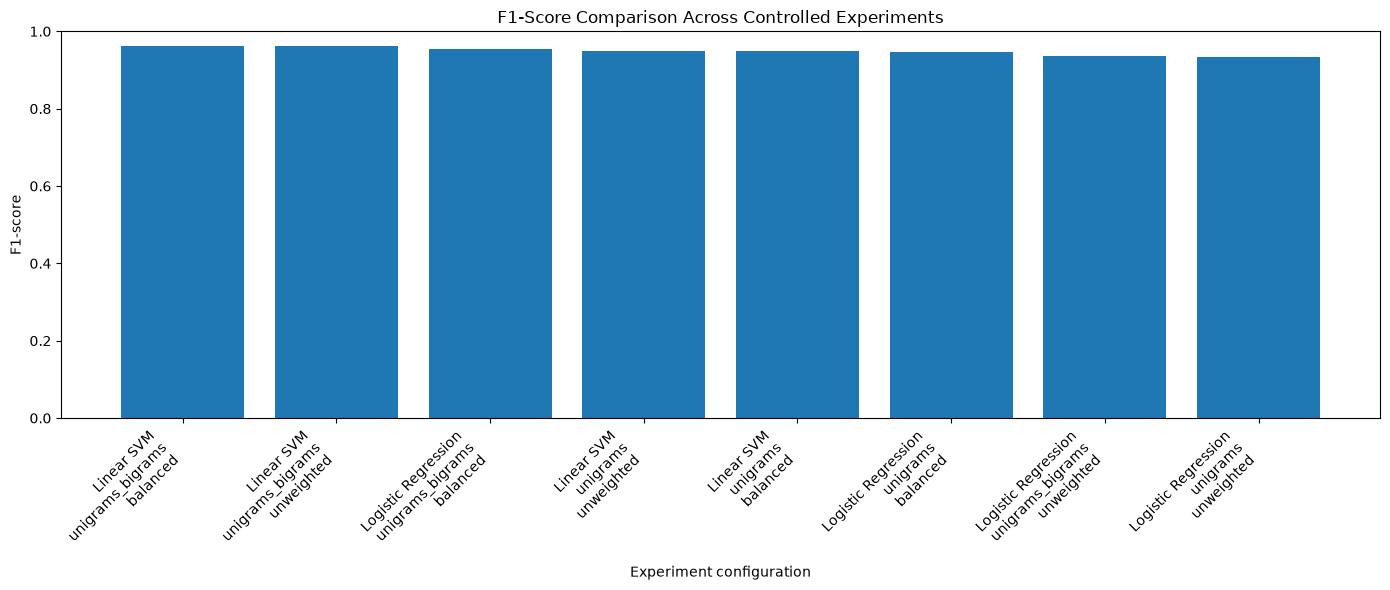

In [10]:
import matplotlib.pyplot as plt

plot_df = results_df.copy()

plot_df["configuration"] = (
    plot_df["model"]
    + "\n"
    + plot_df["ngram_configuration"]
    + "\n"
    + plot_df["class_weight"]
)

plt.figure(figsize=(14, 6))

plt.bar(
    plot_df["configuration"],
    plot_df["f1_score"]
)

plt.title("F1-Score Comparison Across Controlled Experiments")
plt.xlabel("Experiment configuration")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [11]:
best_experiment = results_df.iloc[0]

print("Best experiment based on F1-score:")
print(best_experiment["experiment"])

print("\nMetrics:")
print(f"Accuracy:          {best_experiment['accuracy']:.4f}")
print(f"Balanced accuracy: {best_experiment['balanced_accuracy']:.4f}")
print(f"Precision:         {best_experiment['precision']:.4f}")
print(f"Recall:            {best_experiment['recall']:.4f}")
print(f"F1-score:          {best_experiment['f1_score']:.4f}")

print("\nConfusion matrix counts:")
print("True Negative :", best_experiment["true_negative"])
print("False Positive:", best_experiment["false_positive"])
print("False Negative:", best_experiment["false_negative"])
print("True Positive  :", best_experiment["true_positive"])

Best experiment based on F1-score:
Linear SVM | unigrams_bigrams | balanced

Metrics:
Accuracy:          0.9760
Balanced accuracy: 0.9649
Precision:         0.9947
Recall:            0.9323
F1-score:          0.9625

Confusion matrix counts:
True Negative : 1221
False Positive: 3
False Negative: 41
True Positive  : 565


In [12]:
best_name = best_experiment["experiment"]

best_predictions = experiment_predictions[best_name]["predictions"]

print("Classification report for:")
print(best_name)
print()

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Not security-related",
            "Security-related"
        ],
        zero_division=0
    )
)

Classification report for:
Linear SVM | unigrams_bigrams | balanced

                      precision    recall  f1-score   support

Not security-related       0.97      1.00      0.98      1224
    Security-related       0.99      0.93      0.96       606

            accuracy                           0.98      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.98      0.98      0.98      1830

